## 18. Μη επιβλεπόμενη μηχανική μάθηση

<!-- book-intro-cell -->
### Εισαγωγή από το βιβλίο

Μέχρι τώρα, σε πολλά προβλήματα μηχανικής μάθησης, είχαμε ένα σαφές σημείο αναφοράς. Κάθε παράδειγμα συνοδευόταν από μια σωστή απάντηση, και ο στόχος ήταν να εκπαιδεύσουμε ένα μοντέλο για να την προβλέπει καλά. Η επιτυχία μετριόταν με κάποιο μέτρο αξιολόγησης ως προς κάποιο σημείο αναφοράς (ground truth).

Στη μη επιβλεπόμενη μάθηση, αυτό το σημείο αναφοράς απουσιάζει. Δεν υπάρχει σωστή ομαδοποίηση, ούτε μία μοναδική σωστή αναπαράσταση της δομής των δεδομένων. Έτσι, αντί να προσπαθούμε να προβλέψουμε κάτι προκαθορισμένο, προσπαθούμε να μελετήσουμε τις φυσικές ομάδες που πιθανώς υπάρχουν στα δεδομένα, πώς κατανέμονται τα δεδομένα στον χώρο, και άλλα παρόμοια ερωτήματα.

Με αυτή την έννοια, η μη επιβλεπόμενη μάθηση μοιάζει περισσότερο με διαδικασία εξερεύνησης παρά με διαδικασία πρόβλεψης. Αντί να εκπαιδεύουμε ένα μοντέλο, προσπαθούμε να κατανοήσουμε τη δομή των δεδομένων. Επίσης, πριν ορίσουμε στόχους και ετικέτες, πριν σχεδιάσουμε προβλεπτικά μοντέλα, μπορούμε να δούμε τι περιέχουν τα δεδομένα, ποιες είναι οι βασικές τους μορφές, αλλά και αν υπάρχουν μοτίβα.


### 18.1 Μείωση διάστασης

#### PCA

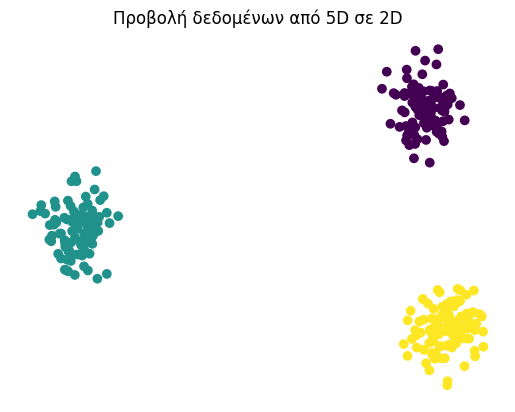

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA

# Δεδομένα σε 5 διαστάσεις
X, y = make_blobs(n_samples=300, centers=3, n_features=5, random_state=42)

# Μείωση σε 2 διαστάσεις
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

# Οπτικοποίηση
plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y)
plt.title("Προβολή δεδομένων από 5D σε 2D")
plt.axis("off")
plt.show()

In [2]:
print("Κύριες συνιστώσες:")
print(pca.components_)

print("\nΕξηγούμενη διακύμανση:")
print(pca.explained_variance_ratio_)

Κύριες συνιστώσες:
[[ 0.01829834  0.84337094 -0.0675391  -0.19510633 -0.49574452]
 [ 0.66562473  0.07500589 -0.18777055  0.71108025 -0.10210256]]

Εξηγούμενη διακύμανση:
[0.81919278 0.15822046]


In [8]:
pca_full = PCA().fit(X)
cumulative = pca_full.explained_variance_ratio_.cumsum()
print(cumulative)

[0.81919278 0.97741324 0.98564613 0.99317839 1.        ]


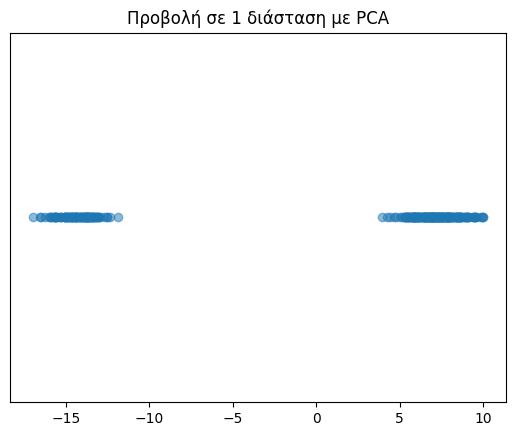

In [5]:
pca_1d = PCA(n_components=1)
X_1d = pca_1d.fit_transform(X)

plt.figure()
plt.scatter(X_1d, np.zeros_like(X_1d), alpha=0.5)
plt.title("Προβολή σε 1 διάσταση με PCA")
plt.yticks([])
plt.show()

In [6]:
pca_full = PCA().fit(X)
cumulative = pca_full.explained_variance_ratio_.cumsum()

print(cumulative)

[0.81919278 0.97741324 0.98564613 0.99317839 1.        ]


#### TSNE

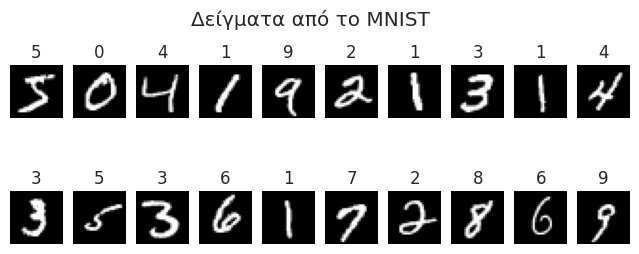

In [27]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# Φόρτωση δεδομένων
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"][:20], mnist["target"][:20]
y = y.astype(int)

# Εμφάνιση μερικών εικόνων
plt.figure(figsize=(8, 3))
for i in range(20):
    plt.subplot(2, 10, i+1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')
    plt.title(y[i])
    plt.axis('off')
plt.suptitle("Δείγματα από το MNIST")
plt.show()

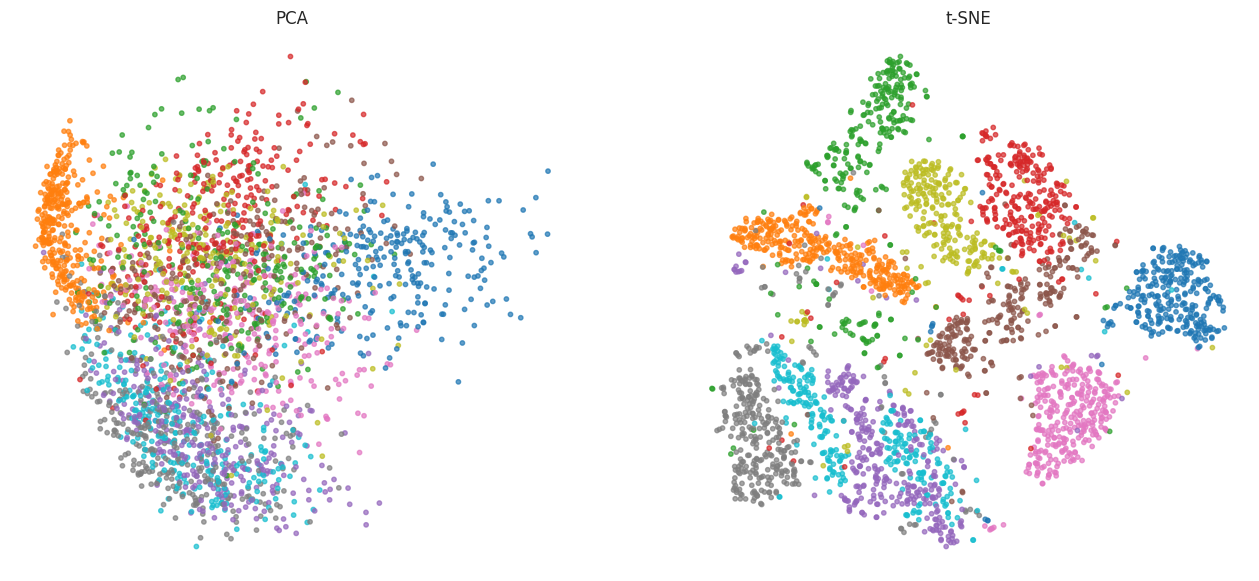

In [28]:
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Υποσύνολο για ταχύτητα
X_small, y_small = mnist["data"][:3000], mnist["target"][:3000].astype(int)

# PCA
X_pca = PCA(n_components=2).fit_transform(X_small)

# t-SNE
tsne = TSNE(n_components=2, perplexity=40, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_small)

# Οπτικοποίηση
fig, ax = plt.subplots(1, 2, figsize=(16, 7))
sns.set_theme(style="white")

# PCA plot
scatter_pca = ax[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_small, cmap='tab10', s=10, alpha=0.7)
ax[0].set_title("PCA")
ax[0].axis('off')

# t-SNE plot
scatter_tsne = ax[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_small, cmap='tab10', s=10, alpha=0.7)
ax[1].set_title("t-SNE")
ax[1].axis('off')

plt.show()

#### UMAP

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


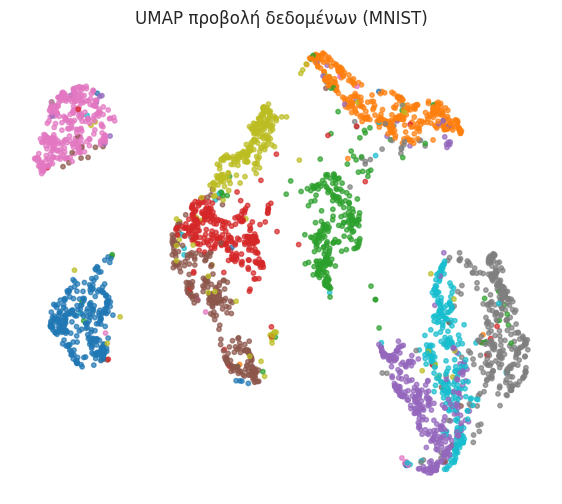

In [29]:
import umap

# UMAP
reducer = umap.UMAP(n_components=2, n_neighbors=15, random_state=42)
X_umap = reducer.fit_transform(X_small)

plt.figure(figsize=(7, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y_small, cmap='tab10', s=10, alpha=0.7)
plt.title("UMAP προβολή δεδομένων (MNIST)")
plt.axis("off")
plt.show()

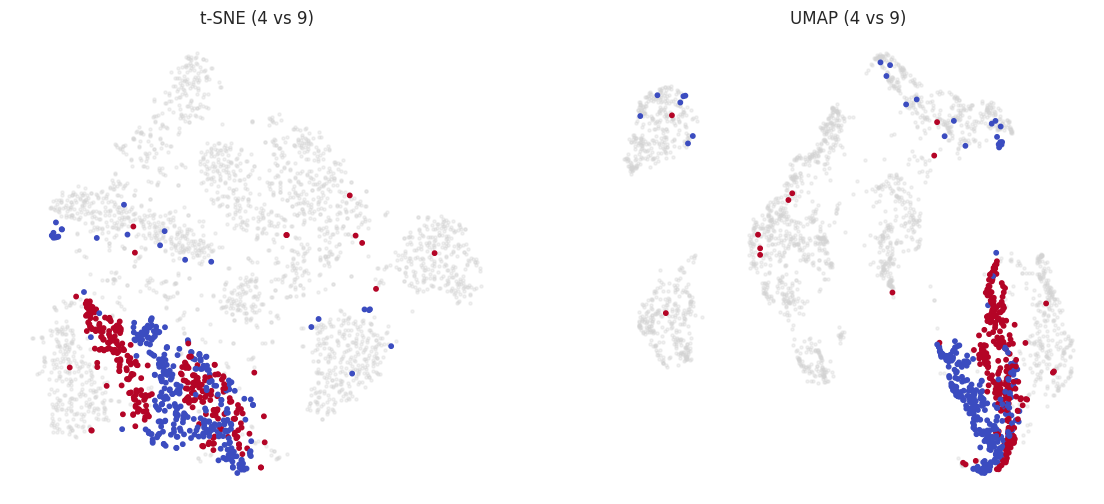

In [38]:
mask_49 = np.isin(y_small, [4, 9])
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
# --- t-SNE ---
ax[0].scatter(X_tsne[:, 0], X_tsne[:, 1], color='lightgray', s=5, alpha=0.3)
ax[0].scatter(X_tsne[mask_35, 0], X_tsne[mask_35, 1],
              c=y_small[mask_35], cmap='coolwarm', s=10)
ax[0].set_title("t-SNE (4 vs 9)")
ax[0].axis('off')
# --- UMAP ---
ax[1].scatter(X_umap[:, 0], X_umap[:, 1], color='lightgray', s=5, alpha=0.3)
ax[1].scatter(X_umap[mask_49, 0], X_umap[mask_49, 1],
              c=y_small[mask_35], cmap='coolwarm', s=10)
ax[1].set_title("UMAP (4 vs 9)")
ax[1].axis('off');

### 18.2 Ομαδοποίηση

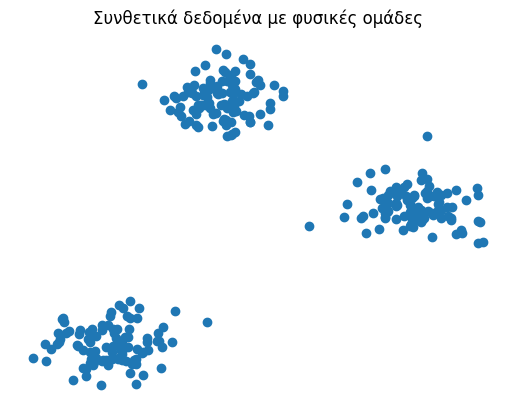

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Δημιουργία συνθετικών δεδομένων (3 "σύννεφα")
X, y = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.2,
    random_state=42
)

# Οπτικοποίηση
plt.figure()
plt.scatter(X[:, 0], X[:, 1])
plt.title("Συνθετικά δεδομένα με φυσικές ομάδες")
plt.axis('off')
plt.show()

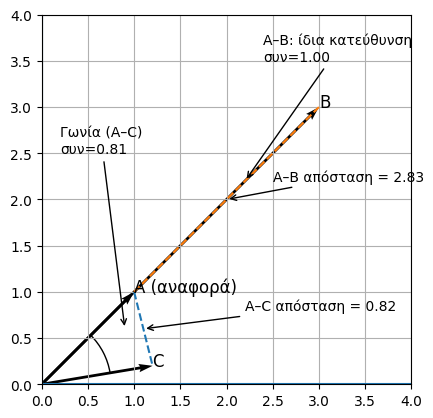

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm
from matplotlib.patches import Arc

# Διανύσματα
A = np.array([1, 1])
B = np.array([3, 3])
C = np.array([1.2, 0.2])

# Συναρτήσεις
def cosine(u, v):
    return np.dot(u, v) / (norm(u) * norm(v))

def euclidean(u, v):
    return norm(u - v)

cos_AB = cosine(A, B)
cos_AC = cosine(A, C)

dist_AB = euclidean(A, B)
dist_AC = euclidean(A, C)

# Γωνίες
angle_A = np.degrees(np.arctan2(A[1], A[0]))
angle_C = np.degrees(np.arctan2(C[1], C[0]))

plt.figure()

# Διανύσματα
plt.quiver(0, 0, A[0], A[1], angles='xy', scale_units='xy', scale=1, linewidth=3)
plt.quiver(0, 0, B[0], B[1], angles='xy', scale_units='xy', scale=1)
plt.quiver(0, 0, C[0], C[1], angles='xy', scale_units='xy', scale=1)

# Labels
plt.text(A[0], A[1], 'A (αναφορά)', fontsize=12)
plt.text(B[0], B[1], 'B', fontsize=12)
plt.text(C[0], C[1], 'C', fontsize=12)

# ✅ Απόσταση A–C
plt.plot([A[0], C[0]], [A[1], C[1]], linestyle='--')
plt.annotate(
    f"A–C απόσταση = {dist_AC:.2f}",
    xy=((A[0]+C[0])/2, (A[1]+C[1])/2),
    xytext=(2.2, 0.8),
    arrowprops=dict(arrowstyle="->")
)

# ✅ Απόσταση A–B (ΝΕΟ)
plt.plot([A[0], B[0]], [A[1], B[1]], linestyle='--')
plt.annotate(
    f"A–B απόσταση = {dist_AB:.2f}",
    xy=((A[0]+B[0])/2, (A[1]+B[1])/2),
    xytext=(2.5, 2.2),
    arrowprops=dict(arrowstyle="->")
)

# Γωνία A–C
arc = Arc(
    (0, 0),
    1.5, 1.5,
    theta1=min(angle_A, angle_C),
    theta2=max(angle_A, angle_C)
)
plt.gca().add_patch(arc)

plt.annotate(
    f"Γωνία (A–C)\nσυν={cos_AC:.2f}",
    xy=(0.9, 0.6),
    xytext=(0.2, 2.5),
    arrowprops=dict(arrowstyle="->")
)

# Cosine A–B
plt.annotate(
    f"A–B: ίδια κατεύθυνση\nσυν={cos_AB:.2f}",
    xy=(2.2, 2.2),
    xytext=(2.4, 3.5),
    arrowprops=dict(arrowstyle="->")
)

# Axes
plt.xlim(0, 4)
plt.ylim(0, 4)
plt.axhline(0)
plt.axvline(0)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid()
plt.show()

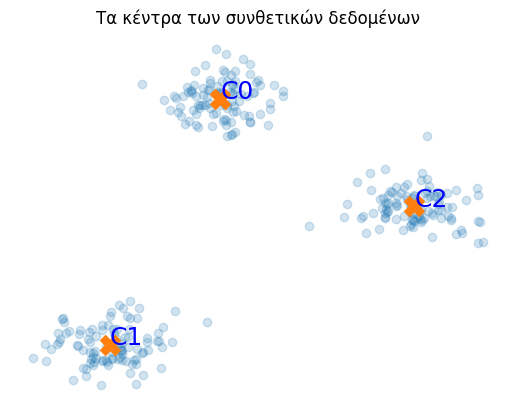

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Δημιουργία συνθετικών δεδομένων (3 "σύννεφα")
X, y = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.2,
    random_state=42
)


# K-means
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

# Οπτικοποίηση
plt.figure()
plt.scatter(X[:, 0], X[:, 1],  alpha=0.2)

# Κεντροειδή
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='X',
    s=200
)

# Labels για centroids
for i, (x, y) in enumerate(centroids):
    plt.text(x, y, f'C{i}', fontsize=18, color='blue')

plt.title("Τα κέντρα των συνθετικών δεδομένων")
plt.axis('off')
plt.show()

#### Ιεραρχική ομαδοποίηση

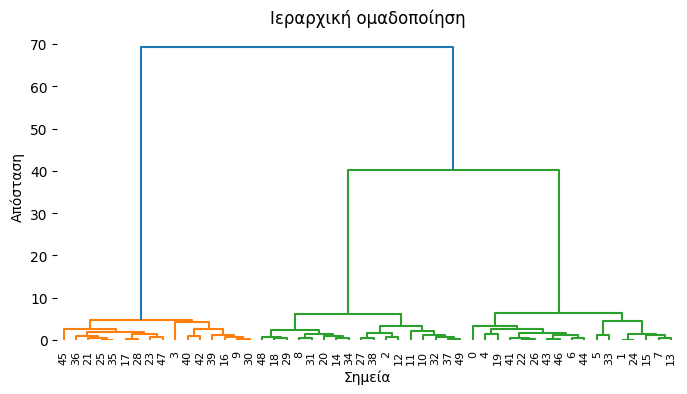

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import linkage, dendrogram
import seaborn as sns

Z = linkage(X, method='ward')
plt.figure(figsize=(8, 4))
dendrogram(Z)
plt.title("Ιεραρχική ομαδοποίηση")
plt.xlabel("Σημεία")
plt.ylabel("Απόσταση")
sns.despine(left=True, bottom=True)
plt.show()

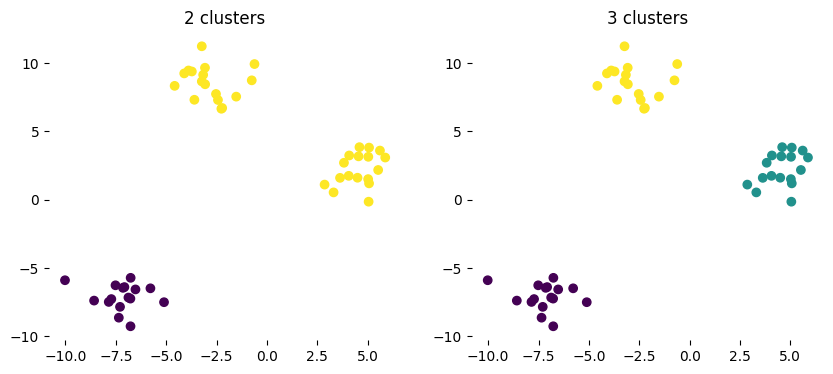

In [ ]:
from scipy.cluster.hierarchy import fcluster

# Επιλογή αριθμού clusters
labels_2 = fcluster(Z, t=2, criterion='maxclust')
labels_3 = fcluster(Z, t=3, criterion='maxclust')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X[:, 0], X[:, 1], c=labels_2)
axes[0].set_title("2 clusters")

axes[1].scatter(X[:, 0], X[:, 1], c=labels_3)
axes[1].set_title("3 clusters")
sns.despine(left=True, bottom=True)
plt.show()

#### DBScan

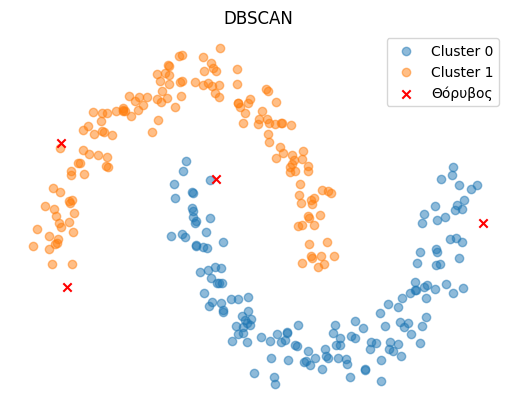

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

# Τα φεγγάρια (με λίγο θόρυβο)
X, _ = make_moons(n_samples=300, noise=0.08, random_state=42)
# Αυστηρό DBSCAN (να εμφανίζεται ο θόρυβος)
dbscan = DBSCAN(eps=0.15, min_samples=5)
labels = dbscan.fit_predict(X)
plt.figure()
# Ξεχωριστή απεικόνιση των ομάδων και του θορύβου
unique_labels = set(labels)
for label in unique_labels:
    mask = labels == label
    if label == -1:
        plt.scatter(
            X[mask, 0],
            X[mask, 1],
            color='red',
            marker='x',
            label='Θόρυβος'
        )
    else:
        plt.scatter(
            X[mask, 0],
            X[mask, 1],
            alpha=0.5,
            label=f'Cluster {label}'
        )
plt.legend()
plt.title("DBSCAN")
plt.axis("off")
plt.show()

### 18.3 Αξιολόγηση λύσεων ομαδοποίησης

Διαφορά μετά την επέκταση:
Micro change: -0.038
Macro change: 0.001


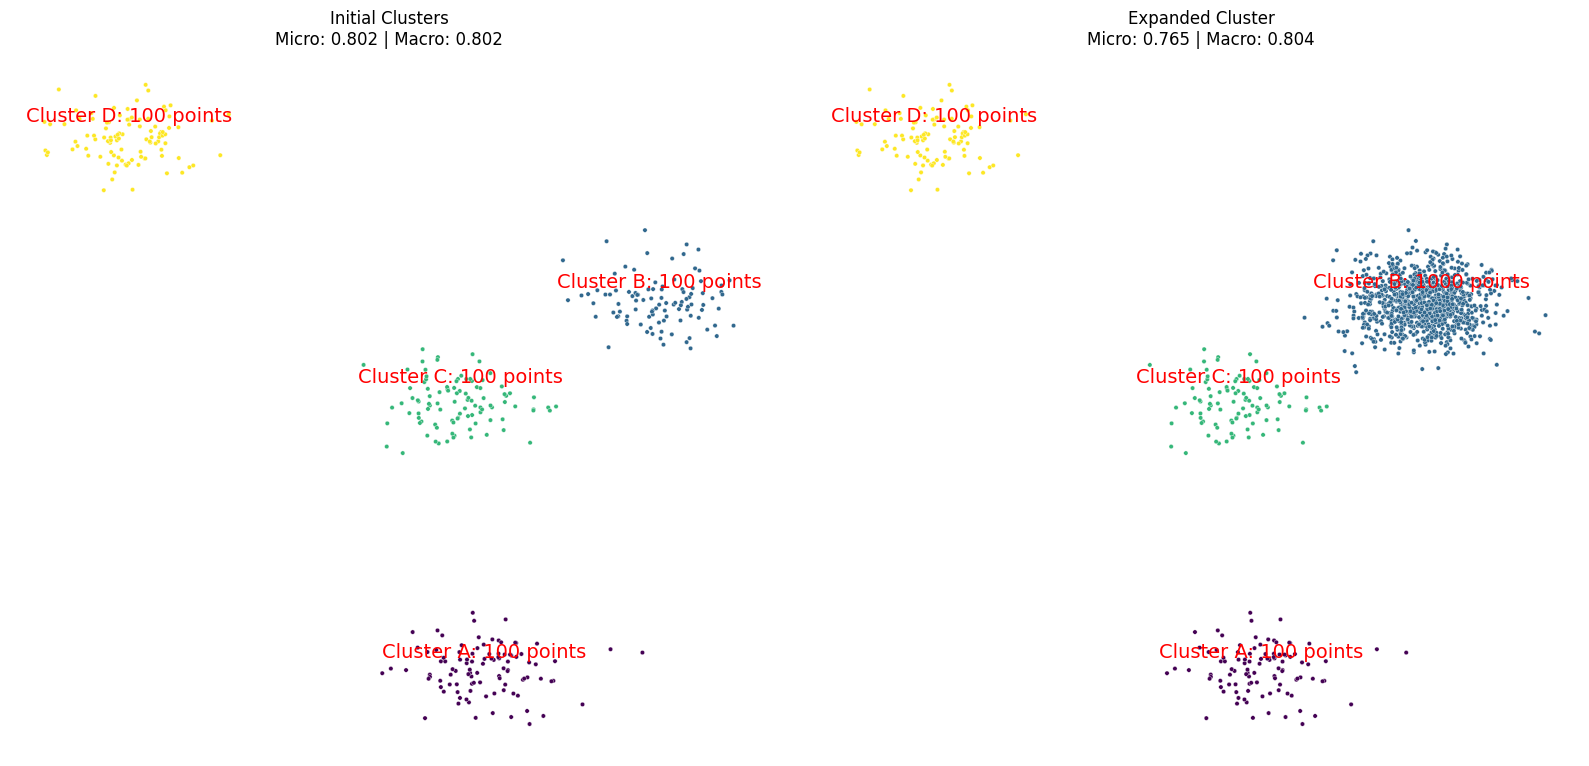

In [ ]:
import numpy as np
np.random.seed(2)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import StandardScaler

def control_sample(X, clustering, balanced=False, sample_size=-1):
    if sample_size < 1: return X, clustering

    X = np.array(X)
    clustering = np.array(clustering)

    if not balanced:
        indices = np.random.choice(len(X), size=sample_size, replace=False)
        return X[indices], clustering[indices]

    unique_clusters, counts = np.unique(clustering, return_counts=True)
    samples_per_cluster = max(1, sample_size // len(unique_clusters))

    sampled_X = []
    sampled_clustering = []

    for cluster in unique_clusters:
        cluster_indices = np.where(clustering == cluster)[0]
        sample_indices = np.random.choice(cluster_indices, size=min(len(cluster_indices), samples_per_cluster), replace=False)
        sampled_X.append(X[sample_indices])
        sampled_clustering.append(clustering[sample_indices])

    sampled_X = np.vstack(sampled_X)
    sampled_clustering = np.hstack(sampled_clustering)

    return sampled_X, sampled_clustering


class SampleSilhouette:

  def __init__(self, X, clustering, sample_size=-1, sample_strategy='micro'):
    self.X, self.clustering = control_sample(X, clustering, balanced=False, sample_size=sample_size)
    self.point_sil = pd.DataFrame({'sil': silhouette_samples(self.X, self.clustering), 'label':self.clustering})

  def macro(self):
    representatives = self.point_sil.groupby('label')['sil'].apply(np.mean)
    return representatives.mean()

  def micro(self):
    return self.point_sil['sil'].mean()

# Function to generate initial clusters
def generate_initial_clusters(n_clusters, points_per_cluster, variance):
    centers = np.random.uniform(-10, 10, (n_clusters, 2))
    X = []
    y_labels = []
    for i, (cx, cy) in enumerate(centers):
        cluster_points = np.random.normal(loc=[cx, cy], scale=variance, size=(points_per_cluster, 2))
        X.append(cluster_points)
        y_labels.append(np.full(points_per_cluster, i))

    X = np.vstack(X)
    y_labels = np.hstack(y_labels)
    return X, y_labels, centers

# Function to add points to one cluster without increasing its diameter
def add_points_to_cluster(X, y_labels, cluster_index, additional_points, variance):
    cluster_points = X[y_labels == cluster_index]
    new_points = np.random.normal(loc=np.mean(cluster_points, axis=0), scale=variance, size=(additional_points, 2))
    X = np.vstack([X, new_points])
    y_labels = np.hstack([y_labels, np.full(additional_points, cluster_index)])
    return X, y_labels

# Parameters
n_clusters = 4
points_per_cluster = 100
variance = 0.5
additional_points = 900
cluster_to_expand = 1
cluster_names = ['Cluster A', 'Cluster B', 'Cluster C', 'Cluster D']

# Generate initial clusters
X, y_labels, centers = generate_initial_clusters(n_clusters, points_per_cluster, variance)

# Compute the Silhouette Scores for the initial clusters
initial_silhouette = SampleSilhouette(X, y_labels)
initial_micro_silhouette_score = initial_silhouette.micro()
initial_macro_silhouette_score = initial_silhouette.macro()

# Visualize initial clusters
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y_labels, palette='viridis', s=10, legend=None)
plt.title(
    f'Initial Clusters\n'
    f'Micro: {initial_micro_silhouette_score:.3f} | '
    f'Macro: {initial_macro_silhouette_score:.3f}'
)
for i, (cx, cy) in enumerate(centers):
    points_in_cluster = np.sum(y_labels == i)
    plt.annotate(f'{cluster_names[i]}: {points_in_cluster} points', (cx, cy), textcoords="offset points", xytext=(0,10), ha='center', fontsize=14, color='red')
plt.tight_layout()
plt.axis('off')
sns.despine(left=True, bottom=True)

# Add points to one of the clusters
X_expanded, y_labels_expanded = add_points_to_cluster(X, y_labels, cluster_to_expand, additional_points, variance)

# Compute the Silhouette Scores for the expanded clusters
expanded_silhouette = SampleSilhouette(X_expanded, y_labels_expanded)
expanded_micro_silhouette_score = expanded_silhouette.micro()
expanded_macro_silhouette_score = expanded_silhouette.macro()

# Visualize expanded clusters
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_expanded[:, 0], y=X_expanded[:, 1], hue=y_labels_expanded, palette='viridis', s=10, legend=None)
plt.title(
    f'Expanded Cluster\n'
    f'Micro: {expanded_micro_silhouette_score:.3f} | '
    f'Macro: {expanded_macro_silhouette_score:.3f}'
)
for i, (cx, cy) in enumerate(centers):
    points_in_cluster = sum(y_labels_expanded == i)
    plt.annotate(f'{cluster_names[i]}: {points_in_cluster} points', (cx, cy), textcoords="offset points", xytext=(0,10), ha='center', fontsize=14, color='red')
plt.tight_layout()
plt.axis('off')
sns.despine(left=True, bottom=True)
print("Διαφορά μετά την επέκταση:")
print(f"Micro change: {expanded_micro_silhouette_score - initial_micro_silhouette_score:.3f}")
print(f"Macro change: {expanded_macro_silhouette_score - initial_macro_silhouette_score:.3f}")
plt.savefig('expanded_clusters.jpg', format='JPG', dpi=300)
plt.show()

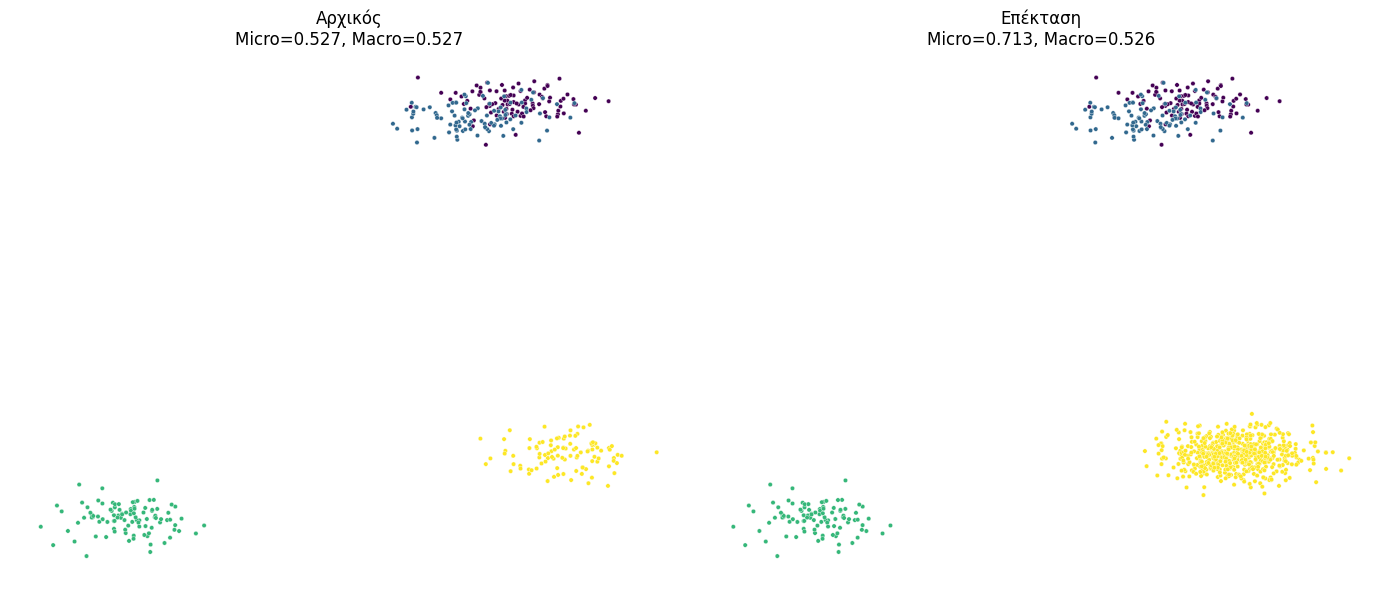

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_samples

np.random.seed(2027)

# Δημιουργία ομάδων
def generate_clusters(n_clusters, points_per_cluster, variance):
    centers = np.random.uniform(-10, 10, (n_clusters, 2))
    X, y = [], []
    for i, (cx, cy) in enumerate(centers):
        pts = np.random.normal([cx, cy], variance, (points_per_cluster, 2))
        X.append(pts)
        y.append(np.full(points_per_cluster, i))
    return np.vstack(X), np.hstack(y), centers

# Προσθήκη σημείων σε μία ομάδα
def expand_cluster(X, y, cluster_id, extra_points, variance):
    cluster_pts = X[y == cluster_id]
    new_pts = np.random.normal(cluster_pts.mean(axis=0), variance, (extra_points, 2))
    X_new = np.vstack([X, new_pts])
    y_new = np.hstack([y, np.full(extra_points, cluster_id)])
    return X_new, y_new

# Υπολογισμός των δύο δεικτών Silhouette
def compute_scores(X, y):
    s = silhouette_samples(X, y)
    micro = s.mean()
    macro = np.mean([s[y == c].mean() for c in np.unique(y)])
    return micro, macro

# Παραμετροποίηση
n_clusters = 4
points_per_cluster = 100
variance = 0.5
extra_points = 500
cluster_to_expand = 3

# Ο αρχικός χώρος
X, y, centers = generate_clusters(n_clusters, points_per_cluster, variance)
micro1, macro1 = compute_scores(X, y)

# Ο εκτεταμένος χώρος
X2, y2 = expand_cluster(X, y, cluster_to_expand, extra_points, variance)
micro2, macro2 = compute_scores(X2, y2)

# Απεικόνιση
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='viridis', s=10, legend=None)
plt.title(f'Αρχικός\nMicro={micro1:.3f}, Macro={macro1:.3f}')
plt.axis('off')

plt.subplot(1, 2, 2)
sns.scatterplot(x=X2[:, 0], y=X2[:, 1], hue=y2, palette='viridis', s=10, legend=None)
plt.title(f'Επέκταση\nMicro={micro2:.3f}, Macro={macro2:.3f}')
plt.axis('off')

plt.tight_layout()
plt.show()

#### Η μέθοδος του αγκώνα

In [ ]:
X, y, centers = generate_clusters(5, 200, 1.0)

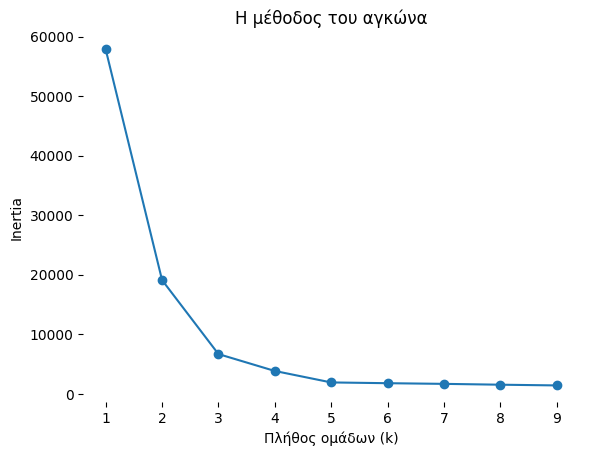

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns

Ks = range(1, 10)
inertias = []
for k in Ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.plot(Ks, inertias, marker='o')
plt.xlabel("Πλήθος ομάδων (k)")
plt.ylabel("Inertia")
plt.title("Η μέθοδος του αγκώνα")
sns.despine(left=True, bottom=True)
plt.show()

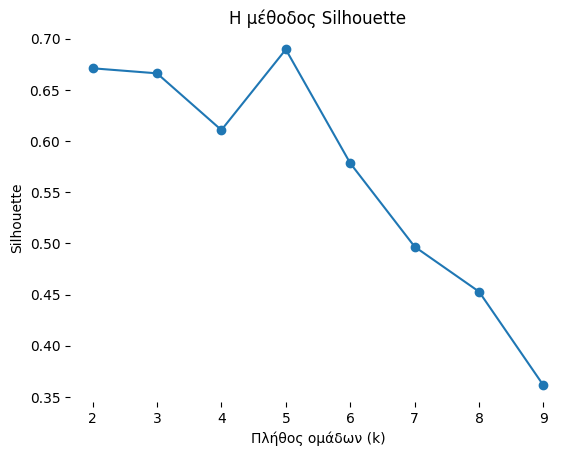

In [ ]:
from sklearn.metrics import silhouette_score

Ks = range(2, 10)
scores = []

for k in Ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)

plt.plot(Ks, scores, marker='o')
plt.xlabel("Πλήθος ομάδων (k)")
plt.ylabel("Silhouette")
plt.title("H μέθοδος Silhouette")
sns.despine(left=True, bottom=True)
plt.show()

### 18.5 Εξωτερικές μετρικές αξιολόγησης

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score

# Ground truth
true_labels = np.array([0, 0, 0, 1, 1, 1])
# Clustering
pred_labels = np.array([1, 1, 1, 0, 0, 0])
# ARI
ari = adjusted_rand_score(true_labels, pred_labels)
print(f"\nARI: {ari:.3f}")
# Contingency table
table = pd.crosstab(true_labels, pred_labels)
table


ARI: 1.000


col_0,0,1
row_0,,
0,0,3
1,3,0


#### NMI

In [ ]:
import numpy as np
from sklearn.metrics import mutual_info_score
from sklearn.metrics import normalized_mutual_info_score
from scipy.stats import entropy


def compute_stats(y_true, y_pred):
   mi = mutual_info_score(y_true, y_pred)
   def H(labels):
       probs = np.bincount(labels) / len(labels)
       return entropy(probs)
   return mi, H(y_true), H(y_pred)


n = 1000


print("Balanced ground truth:")
y_true_bal = np.repeat([0,1,2,3], n//4)
y_pred_bal = y_true_bal.copy()  # perfect match
mi_bal, H_true_bal, H_pred_bal = compute_stats(y_true_bal, y_pred_bal)
print(f"MI: {mi_bal:.3f}, H: {H_true_bal:.3f}")


print("\nImbalanced ground truth:")
y_true_imbal = np.array([0]*850 + [1]*50 + [2]*50 + [3]*50)
y_pred_imbal = y_true_imbal.copy()  # ίδια ποιότητα (perfect)
mi_imbal, H_true_imbal, H_pred_imbal = compute_stats(y_true_imbal, y_pred_imbal)
print(f"MI: {mi_imbal:.3f}, H: {H_true_imbal:.3f}")


print("\nNMI comparison:")
nmi_bal = normalized_mutual_info_score(y_true_bal, y_pred_bal)
nmi_imbal = normalized_mutual_info_score(y_true_imbal, y_pred_imbal)
print(f"Balanced NMI: {nmi_bal:.3f}")
print(f"Imbalanced NMI: {nmi_imbal:.3f}")


Balanced ground truth:
MI: 1.386, H: 1.386

Imbalanced ground truth:
MI: 0.588, H: 0.588

NMI comparison:
Balanced NMI: 1.000
Imbalanced NMI: 1.000


### 18.6 Εφαρμογή: Ομαδοποίηση ελληνικών παροιμιών

In [ ]:
import pandas as pd

seen = pd.read_csv(
    'https://github.com/greek-proverb-atlas/proverbs.gr/raw/refs/heads/main/data/balanced_corpus_2.csv'
)

texts = seen['text'].astype(str).tolist()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(texts)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples
from tqdm.notebook import tqdm

Ks = range(2, 15)
micro_scores, macro_scores = [], []

def silhouette_micro_macro(X, labels):
    s = silhouette_samples(X, labels)
    micro = s.mean()
    macro = np.mean([s[labels == c].mean() for c in np.unique(labels)])
    return micro, macro

for k in tqdm(Ks):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    micro, macro = silhouette_micro_macro(X, labels)
    micro_scores.append(micro)
    macro_scores.append(macro)

best_k_micro = Ks[np.argmax(micro_scores)]
best_k_macro = Ks[np.argmax(macro_scores)]

print("Best k (micro):", best_k_micro)
print("Best k (macro):", best_k_macro)

  0%|          | 0/13 [00:00<?, ?it/s]

Best k (micro): 14
Best k (macro): 10


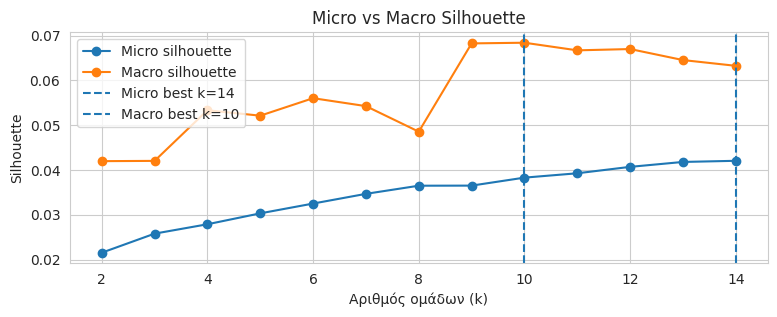

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

plt.figure(figsize=(9,3))
plt.plot(Ks, micro_scores, marker='o', label='Micro silhouette')
plt.plot(Ks, macro_scores, marker='o', label='Macro silhouette')

plt.axvline(best_k_micro, linestyle='--', label=f'Micro best k={best_k_micro}')
plt.axvline(best_k_macro, linestyle='--', label=f'Macro best k={best_k_macro}')

plt.xlabel("Αριθμός ομάδων (k)")
plt.ylabel("Silhouette")
plt.title("Micro vs Macro Silhouette")
plt.legend()
plt.show()
sns.despine()

In [ ]:
kmeans_micro = KMeans(n_clusters=best_k_micro, random_state=42)
kmeans_macro = KMeans(n_clusters=best_k_macro, random_state=42)

kmeans_micro.fit(X)
kmeans_macro.fit(X)

KMeans(n_clusters=10, random_state=42)

In [ ]:
gold = pd.read_csv('cluster_annotations.csv')

gold_texts = gold['text'].astype(str).tolist()
X_gold = vectorizer.transform(gold_texts)

In [ ]:
gold_pred_micro = kmeans_micro.predict(X_gold)
gold_pred_macro = kmeans_macro.predict(X_gold)

In [ ]:
from sklearn.metrics import silhouette_samples, adjusted_rand_score, normalized_mutual_info_score
import numpy as np

def internal_assess(X, labels):
    point_sils = pd.DataFrame({'sil': silhouette_samples(X, labels), 'label':labels})
    representatives = point_sils.groupby('label')['sil'].apply(np.mean)
    print(f'Silhouette (macro): {representatives.mean():.3f} ({representatives.sem():.3f})')
    print(f'Silhouette (micro): {point_sils.sil.mean():.3f}')


def external_assess(labels, true_labels):
    ari = adjusted_rand_score(true_labels, labels)
    nmi = normalized_mutual_info_score(true_labels, labels)
    return ari, nmi

In [ ]:
# micro solution
internal_assess(X_gold, gold_pred_micro)

Silhouette (macro): 0.028 (0.010)
Silhouette (micro): 0.040


In [ ]:
# macro solution
internal_assess(X_gold, gold_pred_macro)

Silhouette (macro): 0.031 (0.014)
Silhouette (micro): 0.039


In [ ]:
gold.sample()

,text,a1,a2,a3,a4,a5,a6,a7,a8,a9,a10
61,"Όποιος πειναει για να πλουτήση, μόν' η πείνα θ...",2,2,2,5,1,1,10,3,4,26


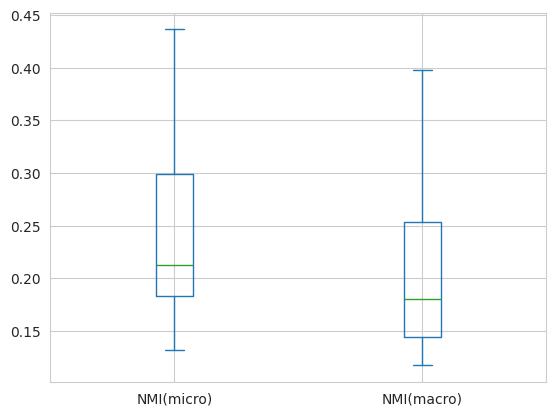

In [ ]:
mics, macs = [], []
for a in [c for c in gold.columns if c.startswith('a')]:
    _, nmi_mic = external_assess(gold_pred_micro, gold[a])
    _, nmi_mac = external_assess(gold_pred_macro, gold[a])
    mics.append(nmi_mic)
    macs.append(nmi_mac)

pd.DataFrame({'NMI(micro)': mics, 'NMI(macro)': macs}).plot.box();